<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/04_6_%EC%9D%BC%EB%B3%80%EB%9F%89_%EB%B9%84%EC%84%A0%ED%98%95_%EB%B3%80%ED%99%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 121713 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [3]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


- 트리 기반 모델은 특성의 순서에만 영향을 받지만 선형 모델과 신경망은 각 특성의 스케일과 분포에 밀접하게 연관됨
- 특성과 타깃 값 사이에 비선형성이 있다면 특히 선형 회귀에서는 모델을 만들기 어려움 ➡️ `log`와 `exp` 함수는 데이터의 스케일을 변경해 선형 모델과 신경망의 성능을 올리는 데 도움을 줌
- `sin`과 `cos` 함수는 주기적 패턴이 들어있는 데이터를 다룰 때 편리
- 대부분의 모델은 각 특성이 (회귀에서는 타깃도) 정규분포와 비슷할 때 최고의 성능 ➡️ `log`나 `exp` 함수를 사용하는 것이 쉽고 효과적 (e.g. 정수 카운트 데이터를 다룰 때)
- 정수 카운트 데이터: 음수가 없으며 특별한 통계 패턴을 따르는 경우가 많음


In [4]:
# 정수 카운트 데이터 로드: 특성은 모두 정수, 응답은 실수

rnd = np.random.RandomState(0)
X_org = rnd.normal(size=(1000, 3))
w = rnd.normal(size=3)

X = rnd.poisson(10 * np.exp(X_org))
y = np.dot(X_org, w)
print(X[:10, 0])

[ 56  81  25  20  27  18  12  21 109   7]


In [5]:
# X[0] 특성 분포: 2가 제일 많으며 큰 값의 수는 빠르게 줄어듦
print(f"특성 출현 횟수:\n{np.bincount(X[:, 0])}")

특성 출현 횟수:
[28 38 68 48 61 59 45 56 37 40 35 34 36 26 23 26 27 21 23 23 18 21 10  9
 17  9  7 14 12  7  3  8  4  5  5  3  4  2  4  1  1  3  2  5  3  8  2  5
  2  1  2  3  3  2  2  3  3  0  1  2  1  0  0  3  1  0  0  0  1  3  0  1
  0  2  0  1  1  0  0  0  0  1  0  0  2  2  0  1  1  0  0  0  0  1  1  0
  0  0  0  0  0  0  1  0  0  0  0  0  1  1  0  0  1  0  0  0  0  0  0  0
  1  0  0  0  0  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  1]


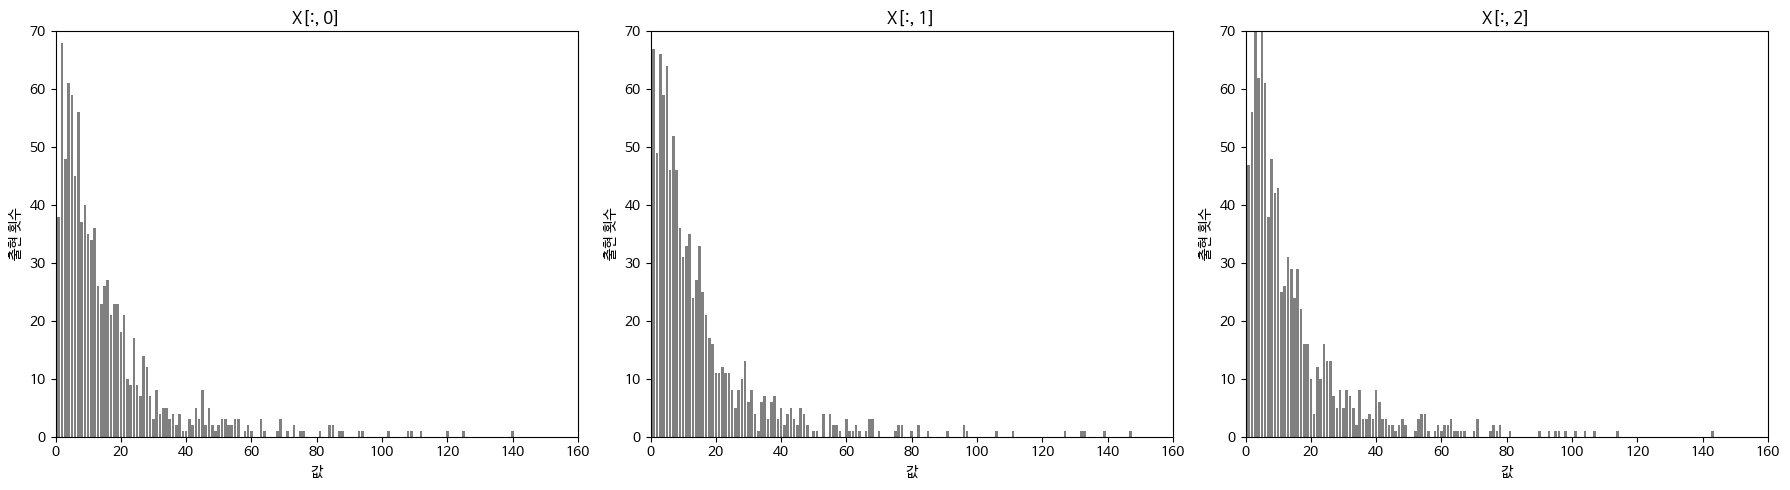

In [8]:
# 특성 값의 히스토그램

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx in range(3):  # X[:,0], X[:,1], X[:,2]
    bins = np.bincount(X[:, idx])

    axes[idx].bar(range(len(bins)), bins, color="grey")
    axes[idx].set_xlim(0, 160)
    axes[idx].set_ylim(0, 70)
    axes[idx].set_title(f"X[:, {idx}]")
    axes[idx].set_xlabel("값")
    axes[idx].set_ylabel("출현 횟수")

plt.tight_layout()
plt.show()

- `X[:,0]`, `X[:,1]`, `X[:,2]` 모두 작은 수치가 많고 큰 수치는 적음
- 선형 모델은 이런 데이터를 잘 처리하지 못함

In [9]:
# 리지 회귀 적용
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
score = Ridge().fit(X_train, y_train).score(X_test, y_test)
print(f"테스트 점수: {round(score, 3)}")

테스트 점수: 0.622


- 낮은 $R^2$ 점수
- 로그 스케일 변환이 도움이 됨
- 데이터에 0이 있으면 `log`함수를 적용하지 못함 ➡️ `log(X+1)` 적용

In [10]:
# 로그 변환

X_train_log = np.log(X_train+1)
X_test_log = np.log(X_test+1)

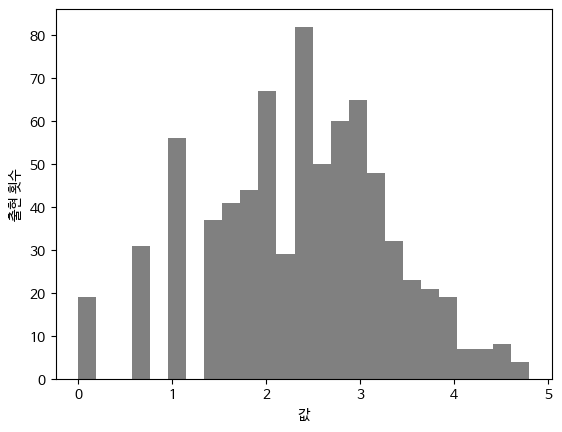

In [11]:
# 로그 변환 후 X[0] 특성 값의 히스토그램
plt.hist(X_train_log[:, 0], bins=25, color="gray")
plt.ylabel("출현 횟수")
plt.xlabel("값")
plt.show()

In [12]:
# 리지 모델 적용
score = Ridge().fit(X_train_log, y_train).score(X_test_log, y_test)
print(f"테스트 점수: {round(score, 3)}")

테스트 점수: 0.875


- 선형 모델에서는 스케일 변환, 분포 변환이 필수적
  - 회귀에서 타깃 변수 `y`를 변환하는 것이 좋을 때도 있음
- 선형 모델이나 나이브 베이즈 모델 같은 덜 복잡한 모델일 경우 구간 분할, 다항식, 상호작용은 모델의 성능에 큰 영향을 줄 수 있음
- 트리 기반 모델은 대부분의 경우 데이터를 명시적으로 변환하지 않아도 됨
- SVM, 최근접 이웃, 신경망 같은 모델은 구간 분할, 다항식, 상호작용으로 이득을 볼 수 있지만, 선형 모델보다는 크지 않음